# Understanding the Impact of State Level Funding on Student Outcomes
## CS 1090A Final Project
### by Alex Fernand, Moniola, Grace Augustine, and Garland Catlette

In [197]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.utils import resample
from scipy.stats import t
from sklearn.metrics import mean_squared_error, r2_score



## Exploratory Data Analysis

In [198]:
df = pd.read_excel("data/StateIndicatorsDatabase_2025.xlsx", sheet_name="Data")

# Filtering data for the years 2009 to 2019 to address missingness
df = df[(df["year"] >= 2009) & (df["year"] <= 2019)]
df.head()

/Users/garlandcatlette/FALL25/CS_1090A/final_project/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,year,stabbr,state_name,statefip,region4,region9,effort,inc_effort,predicted_fedrevpp0_,predicted_fedrevpp10_,...,inc_gap130_ratio,coverage,state_chartershare,inc_pubsch,inc_nonpubsch,pubprv_incratio,case,citation,ruling,casetype
153,2019,AL,Alabama,1,South,East South Central,0.035605,0.038865,431.6210,686.7686,...,0.197983,0.861250,0.000795,82750.59,125697.30,0.658332,NaN,NaN,NaN,NaN
154,2019,AK,Alaska,2,West,Pacific,0.042915,0.053074,753.8663,1773.2300,...,0.225739,0.853597,0.055628,98056.77,87579.52,1.119631,NaN,NaN,NaN,NaN
155,2019,AZ,Arizona,4,West,Mountain,0.026370,0.029332,325.9877,613.1902,...,0.196911,0.895027,0.306565,101541.70,127656.70,0.795428,NaN,NaN,NaN,NaN
156,2019,AR,Arkansas,5,South,West South Central,0.042158,0.042279,512.3929,779.2733,...,0.214611,0.902905,0.075659,79239.53,120330.90,0.658514,NaN,NaN,NaN,NaN
157,2019,CA,California,6,West,Pacific,0.031838,0.038167,421.1313,749.0176,...,0.164208,0.901418,0.141387,125382.30,209634.50,0.598100,NaN,NaN,NaN,NaN


In [199]:
predictors_of_interest = ["year", "state_name", "region4", "region9", "necm_ppcstot_state", "necm_fundinggap_state",
 "tchsalary25_30", "tchsalary31_40", "tchsalary41_50", "tchsalary51_60", "necm_outcomegap_q1", "necm_outcomegap_q2", 
 "necm_outcomegap_q3", "necm_outcomegap_q4", "necm_outcomegap_q5", "fairness_tchph", "inc_gap185_ratio", 
 "inc_gap130_ratio"]
response_var = "necm_outcomegap_state"

#Removed states with missing data for the response variable (Vermont, Alaska, Hawaii)
filtered_df = df[predictors_of_interest + [response_var]].dropna().reset_index(drop=True)
filtered_df.head()

,year,state_name,region4,region9,necm_ppcstot_state,necm_fundinggap_state,tchsalary25_30,tchsalary31_40,tchsalary41_50,tchsalary51_60,necm_outcomegap_q1,necm_outcomegap_q2,necm_outcomegap_q3,necm_outcomegap_q4,necm_outcomegap_q5,fairness_tchph,inc_gap185_ratio,inc_gap130_ratio,necm_outcomegap_state
0,2019,Alabama,South,East South Central,10078.780,-5113.8250,22722.28,26305.53,30608.79,34383.88,0.029665,-0.330956,-0.428685,-0.430291,-0.811346,0.911271,0.242321,0.197983,-0.298386
1,2019,Arizona,West,Mountain,8542.738,-2852.4060,23866.37,27316.04,31145.49,34346.01,0.246770,-0.073577,-0.269651,-0.424496,-0.626824,0.945713,0.243701,0.196911,-0.078379
2,2019,Arkansas,South,West South Central,10147.130,-3977.7690,26109.33,30070.11,33990.20,37660.96,0.101952,-0.143908,-0.247667,-0.315275,-0.574663,1.210944,0.256912,0.214611,-0.167177
3,2019,California,West,Pacific,13433.580,-1159.8540,33505.51,39057.78,45146.67,50639.00,0.404455,0.032169,-0.213023,-0.366004,-0.514552,0.990620,0.203774,0.164208,-0.137851
4,2019,Colorado,West,Mountain,10937.760,32.1782,22873.91,26307.92,30430.89,33815.88,0.336864,0.126460,-0.138817,-0.121889,-0.205673,1.146207,0.208257,0.151715,0.107602


Text(0, 0.5, 'count')

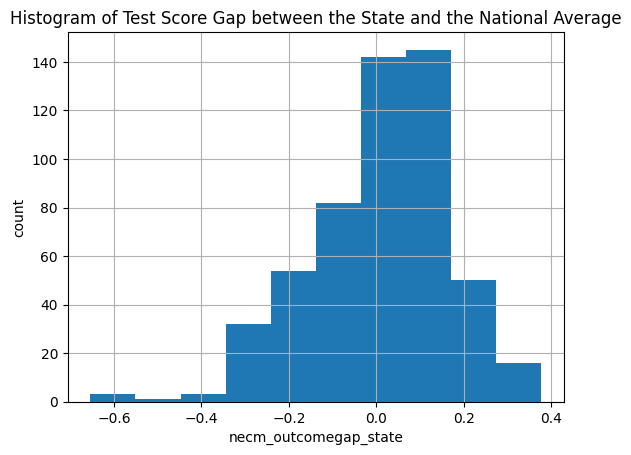

In [200]:
df['necm_outcomegap_state'].hist()
plt.title("Histogram of Test Score Gap between the State and the National Average") 
plt.xlabel("necm_outcomegap_state")
plt.ylabel("count")

In [201]:
summary = pd.DataFrame({
    'NAs'      : filtered_df.isna().sum(),
    'NonNAs'   : filtered_df.notna().sum(),
    'Mean'     : filtered_df.mean(numeric_only=True),
    'Median'   : filtered_df.median(numeric_only=True),
    'STD'      : filtered_df.std(numeric_only=True),
    'IQR'      : filtered_df.quantile(0.75, numeric_only=True) - filtered_df.quantile(0.25, numeric_only=True)
})
summary.index.name = "Figure 1: Summary Statistics of Continous Predictors of Interest"

summary


,NAs,NonNAs,Mean,Median,STD,IQR
Figure 1: Summary Statistics of Continous Predictors of Interest,,,,,,
fairness_tchph,0,517,1.062278,1.040505,0.148055,0.148483
inc_gap130_ratio,0,517,0.194675,0.199068,0.030289,0.034020
inc_gap185_ratio,0,517,0.243414,0.245005,0.034649,0.040210
necm_fundinggap_state,0,517,-209.625479,-420.512100,3844.521952,4686.216000
necm_outcomegap_q1,0,517,0.282291,0.273149,0.225571,0.298808
necm_outcomegap_q2,0,517,0.102992,0.108355,0.213193,0.275957
necm_outcomegap_q3,0,517,0.003604,-0.002099,0.201970,0.299844
necm_outcomegap_q4,0,517,-0.082475,-0.073388,0.198031,0.297626
necm_outcomegap_q5,0,517,-0.301893,-0.298779,0.177266,0.258625


### Visualizing Collinearity

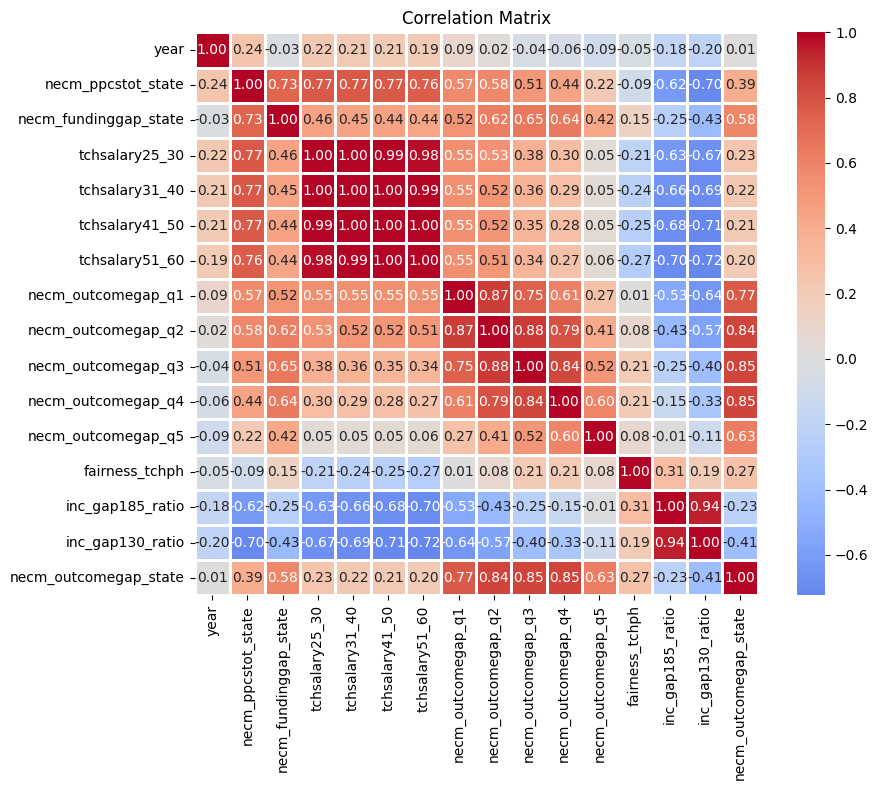

In [231]:
corr_matrix = filtered_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

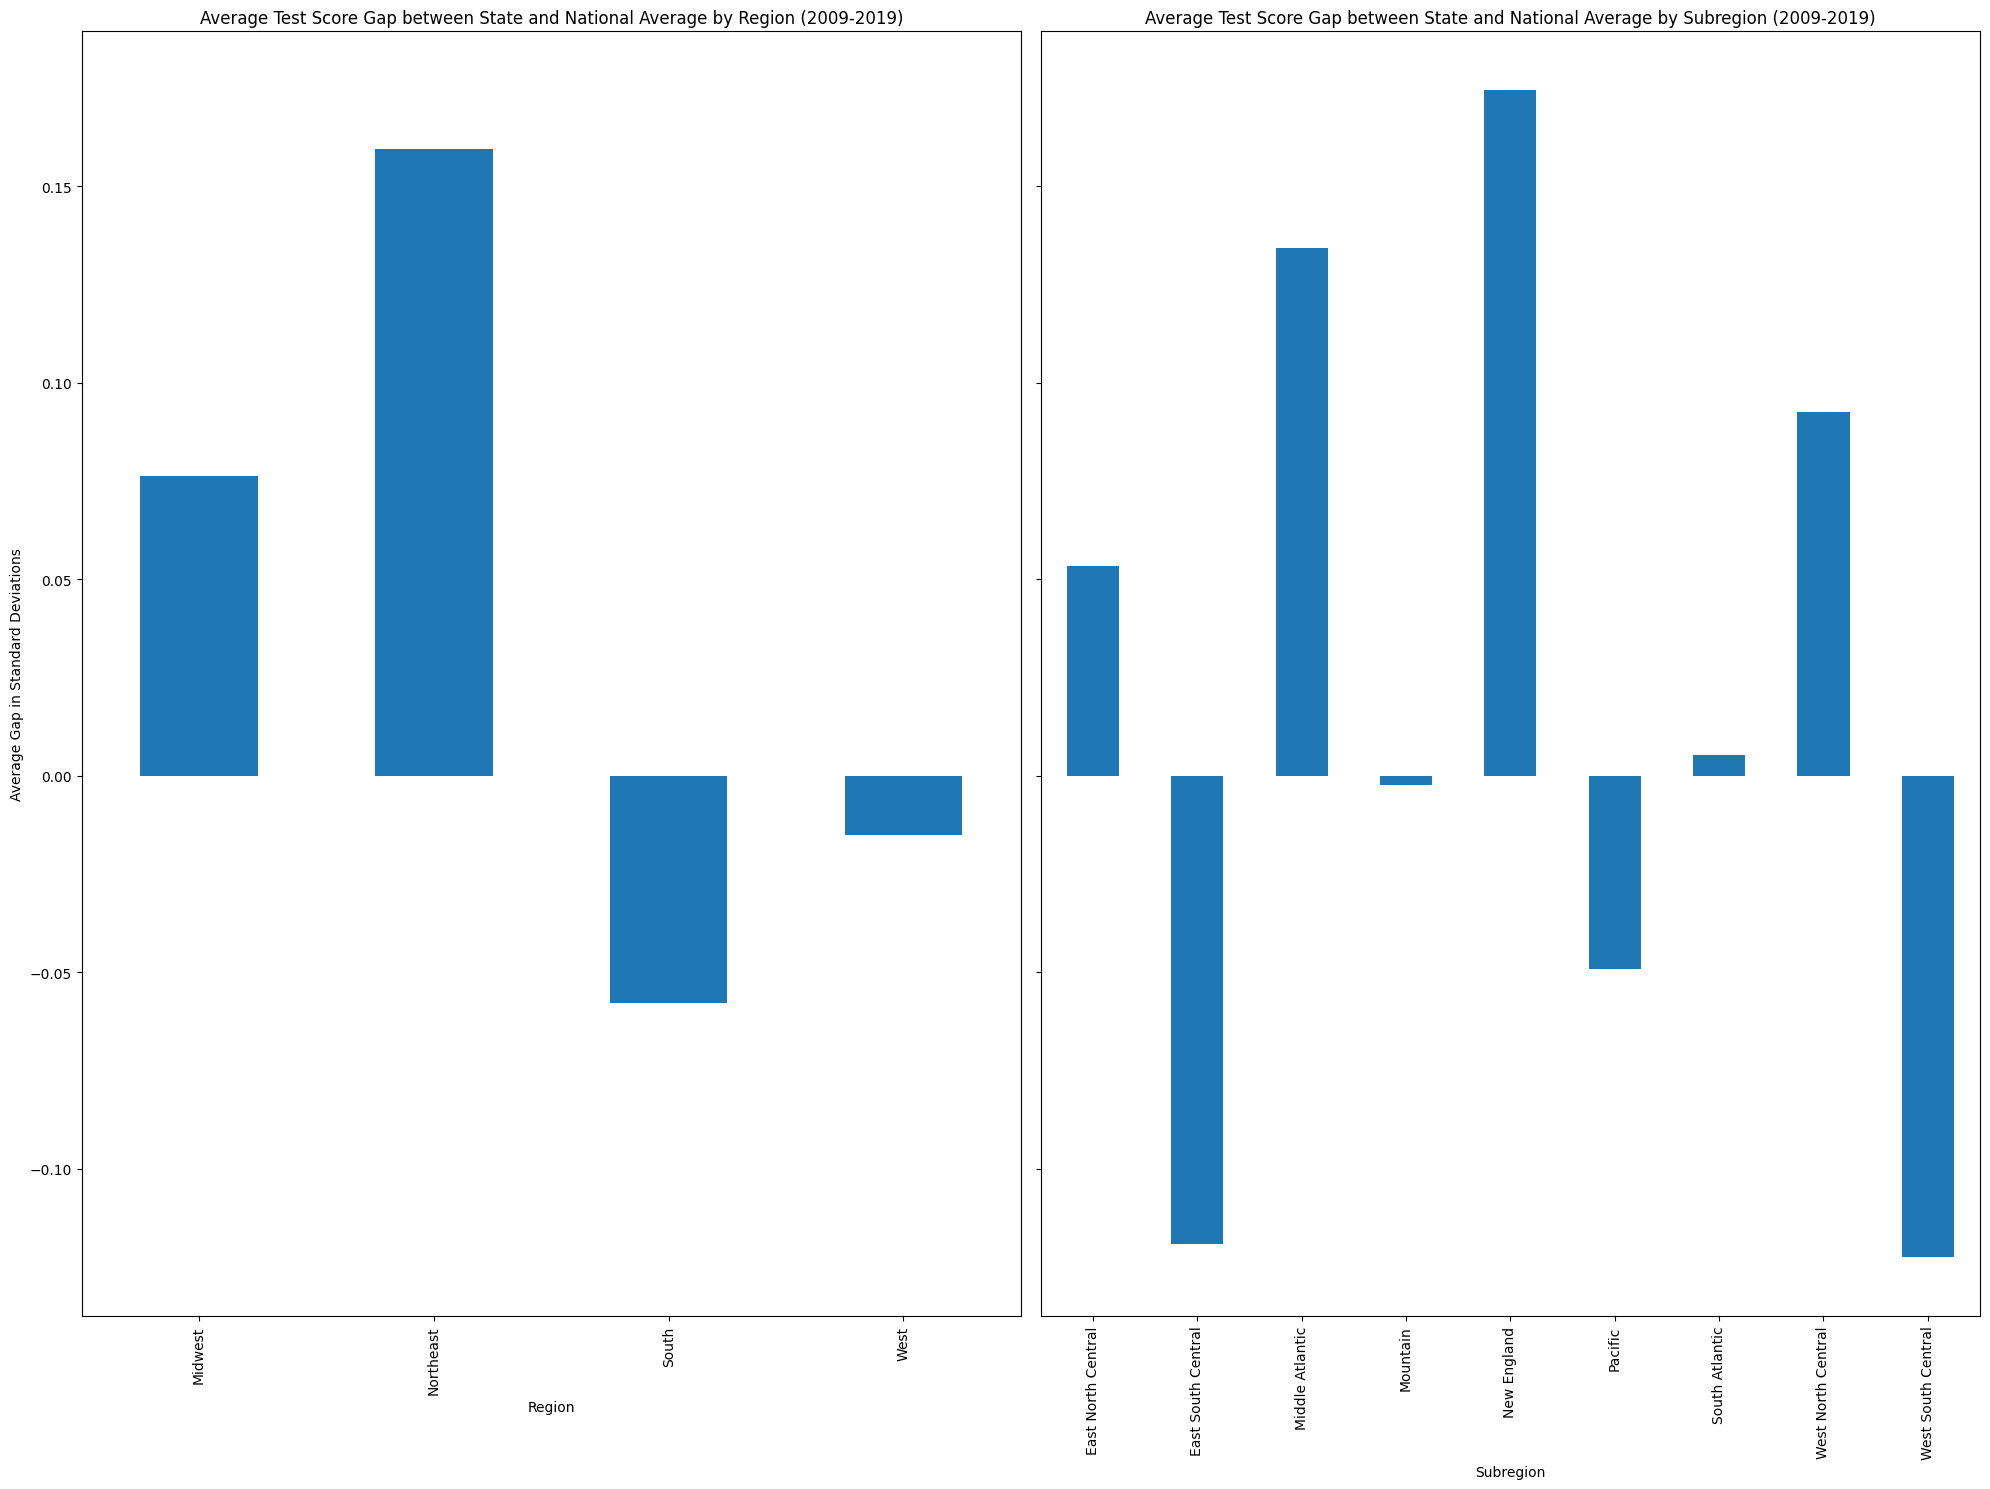

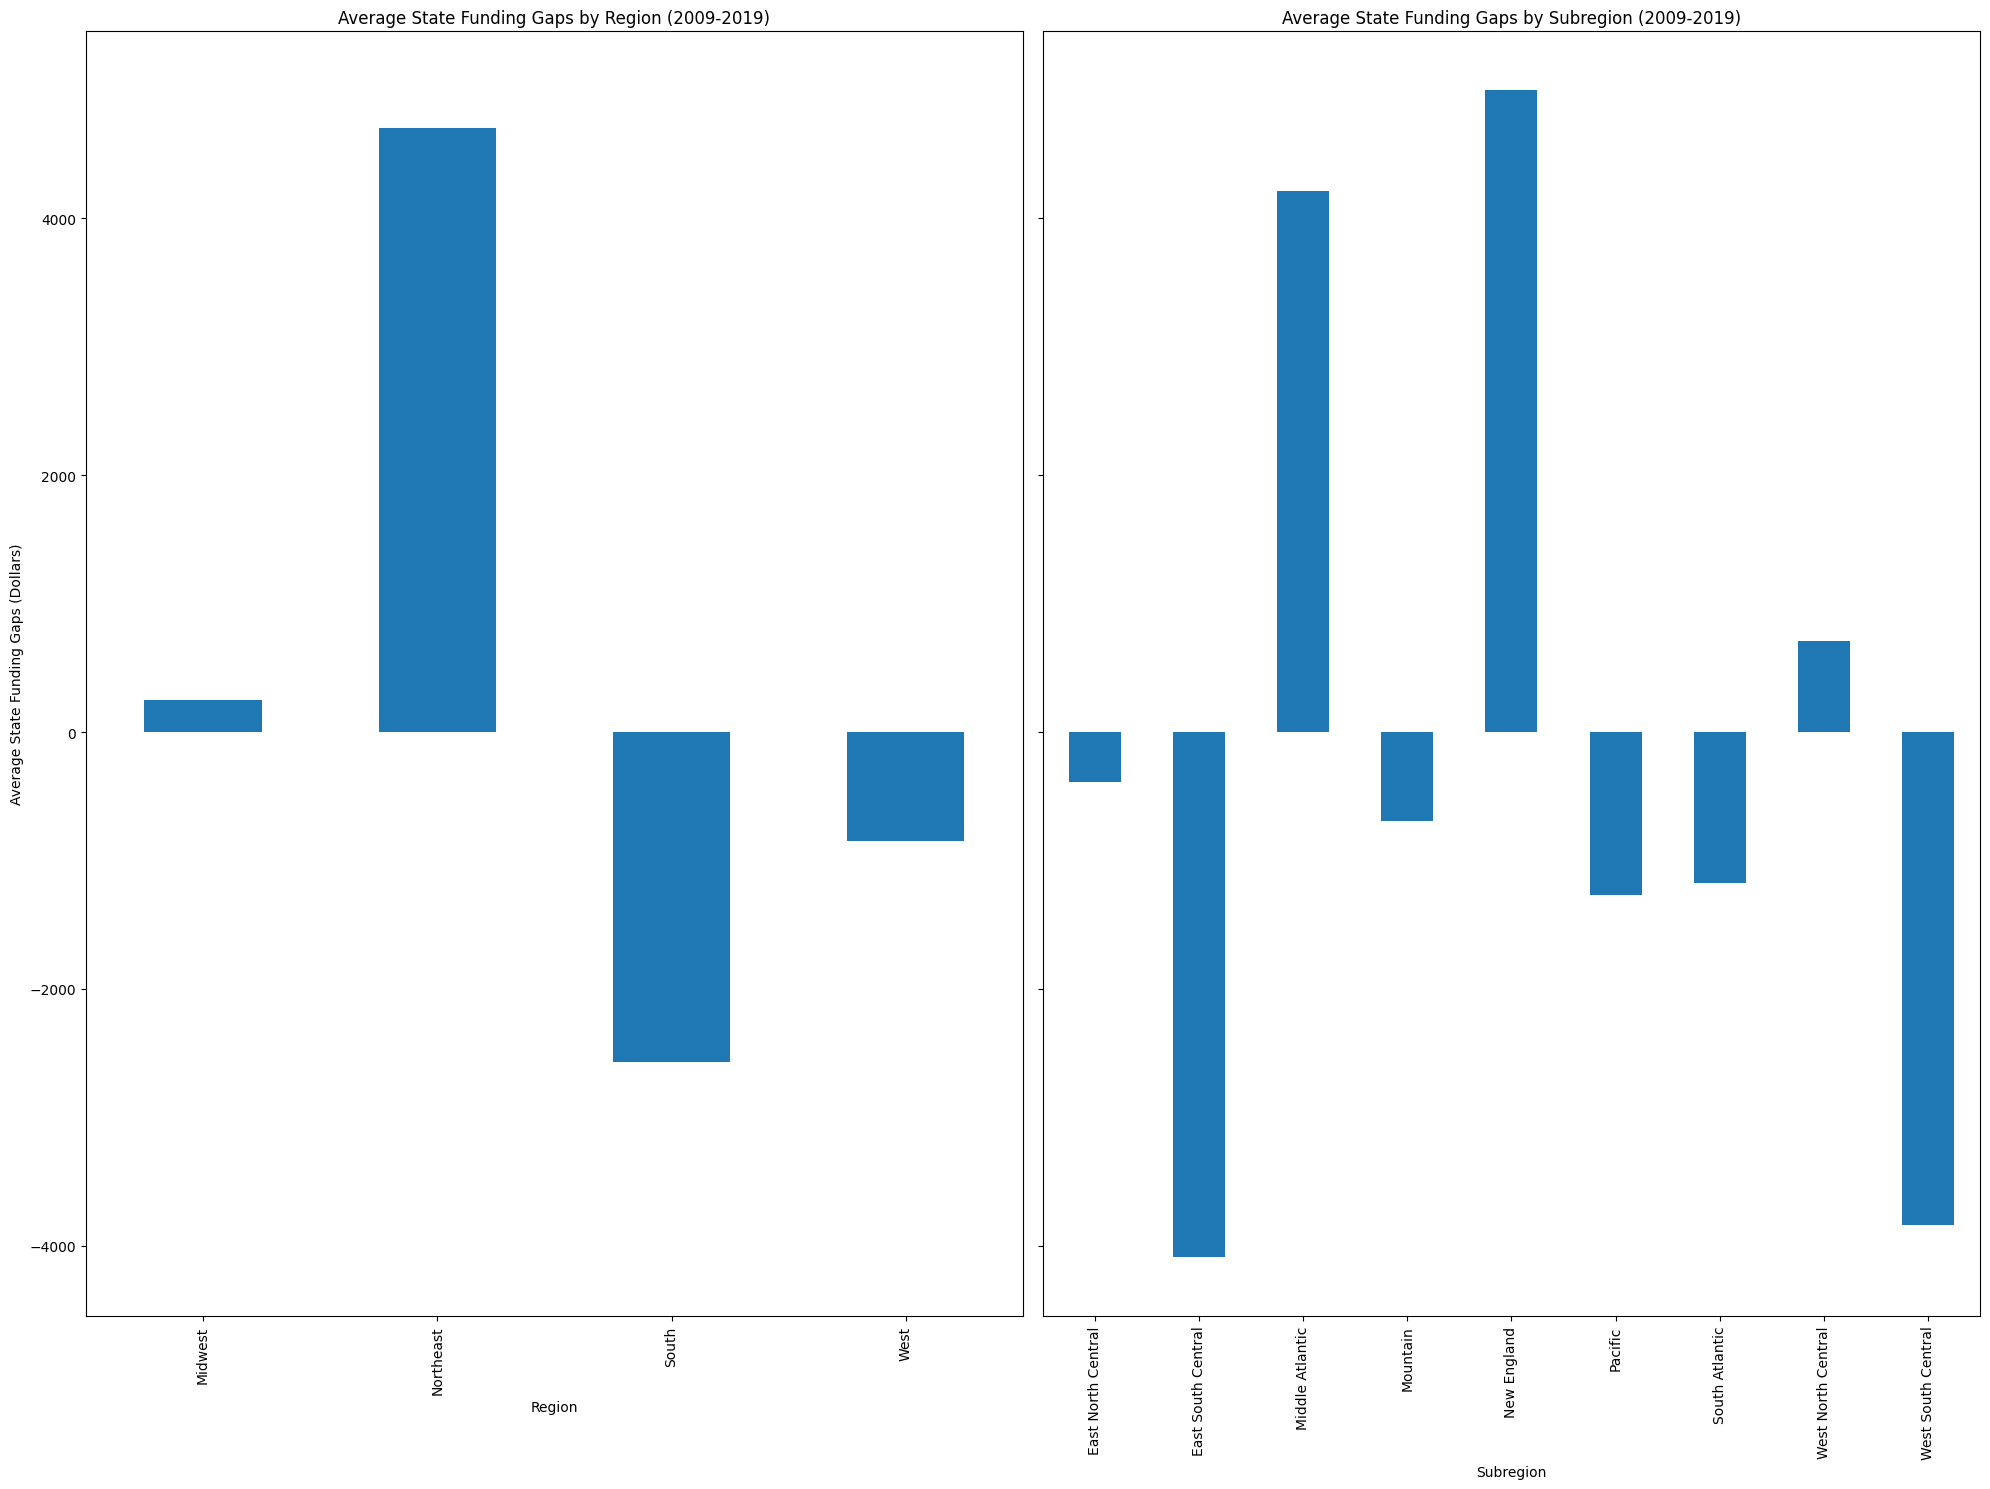

In [203]:
fig, axes = plt.subplots(1, 2, figsize=(20, 15), sharey=True)

filtered_df.groupby("region4")[response_var].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Average Test Score Gap between State and National Average by Region (2009-2019)")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Average Gap in Standard Deviations")

filtered_df.groupby("region9")[response_var].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Average Test Score Gap between State and National Average by Subregion (2009-2019)")
axes[1].set_xlabel("Subregion")
axes[1].set_ylabel("Average Gap in Standard Deviations")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(20, 15), sharey=True)

filtered_df.groupby("region4")["necm_fundinggap_state"].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Average State Funding Gaps by Region (2009-2019)")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Average State Funding Gaps (Dollars)")


filtered_df.groupby("region9")["necm_fundinggap_state"].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Average State Funding Gaps by Subregion (2009-2019)")
axes[1].set_xlabel("Subregion")
axes[1].set_ylabel("Average State Funding Gap (Dollars)")
plt.tight_layout()
plt.show()

### Updating Predictors of Interest

In [204]:
predictors_of_interest = ["necm_fundinggap_state", "necm_outcomegap_q1", "necm_outcomegap_q2", 
 "necm_outcomegap_q3", "necm_outcomegap_q4", "necm_outcomegap_q5", "fairness_tchph", "inc_gap185_ratio", 
 "inc_gap130_ratio"]

### Test Score Gap by State for years 2009 - 2019

##### Noteworthy Observations
* Test scores monotonically grow closer to the national average in Mississippi and the District of Columbia.
* New Hampshire consistently reports test scores above the national average, but test scores monotonically grow closer to the national average from 2013 - 2019.

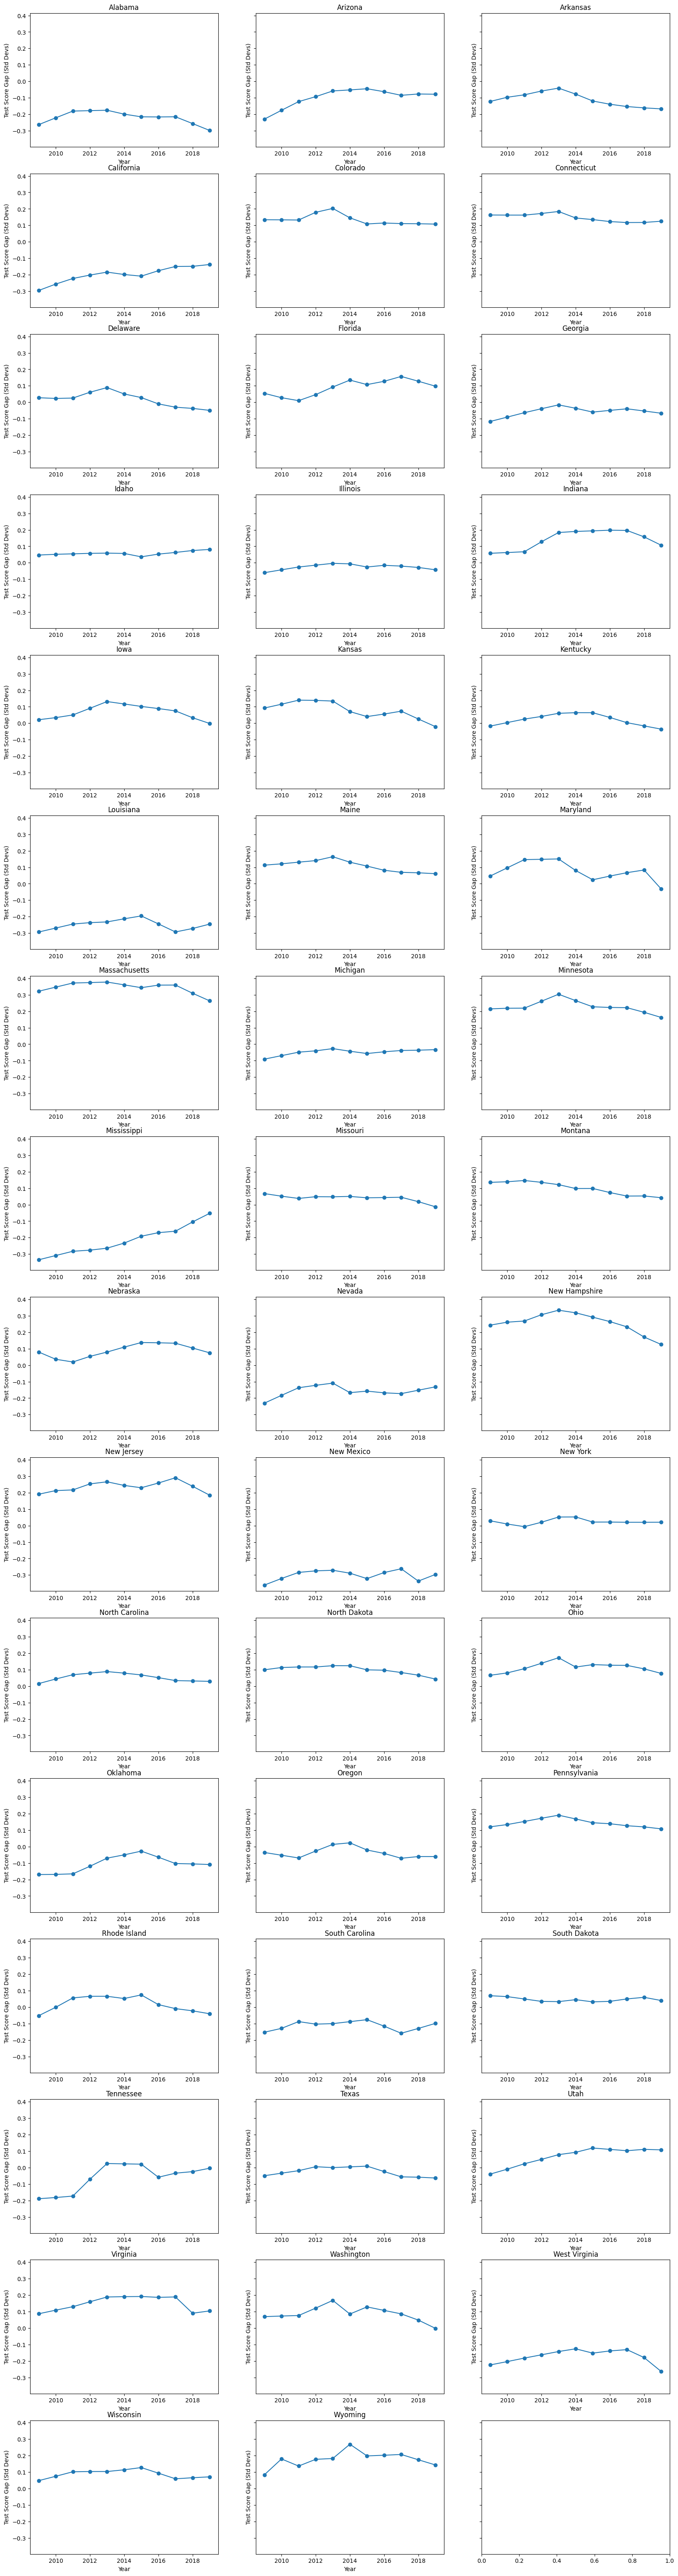

In [205]:
states = filtered_df["state_name"].unique()

fig, axes = plt.subplots(16, 3, figsize=(20, 80), sharey=True)

for state, ax in zip(states, axes.flatten()):
    state_data = filtered_df[filtered_df["state_name"] == state]
    ax.plot(state_data["year"], state_data[response_var], marker='o')
    ax.set_title(state)
    ax.set_xlabel("Year")
    ax.set_ylabel("Test Score Gap (Std Devs)")

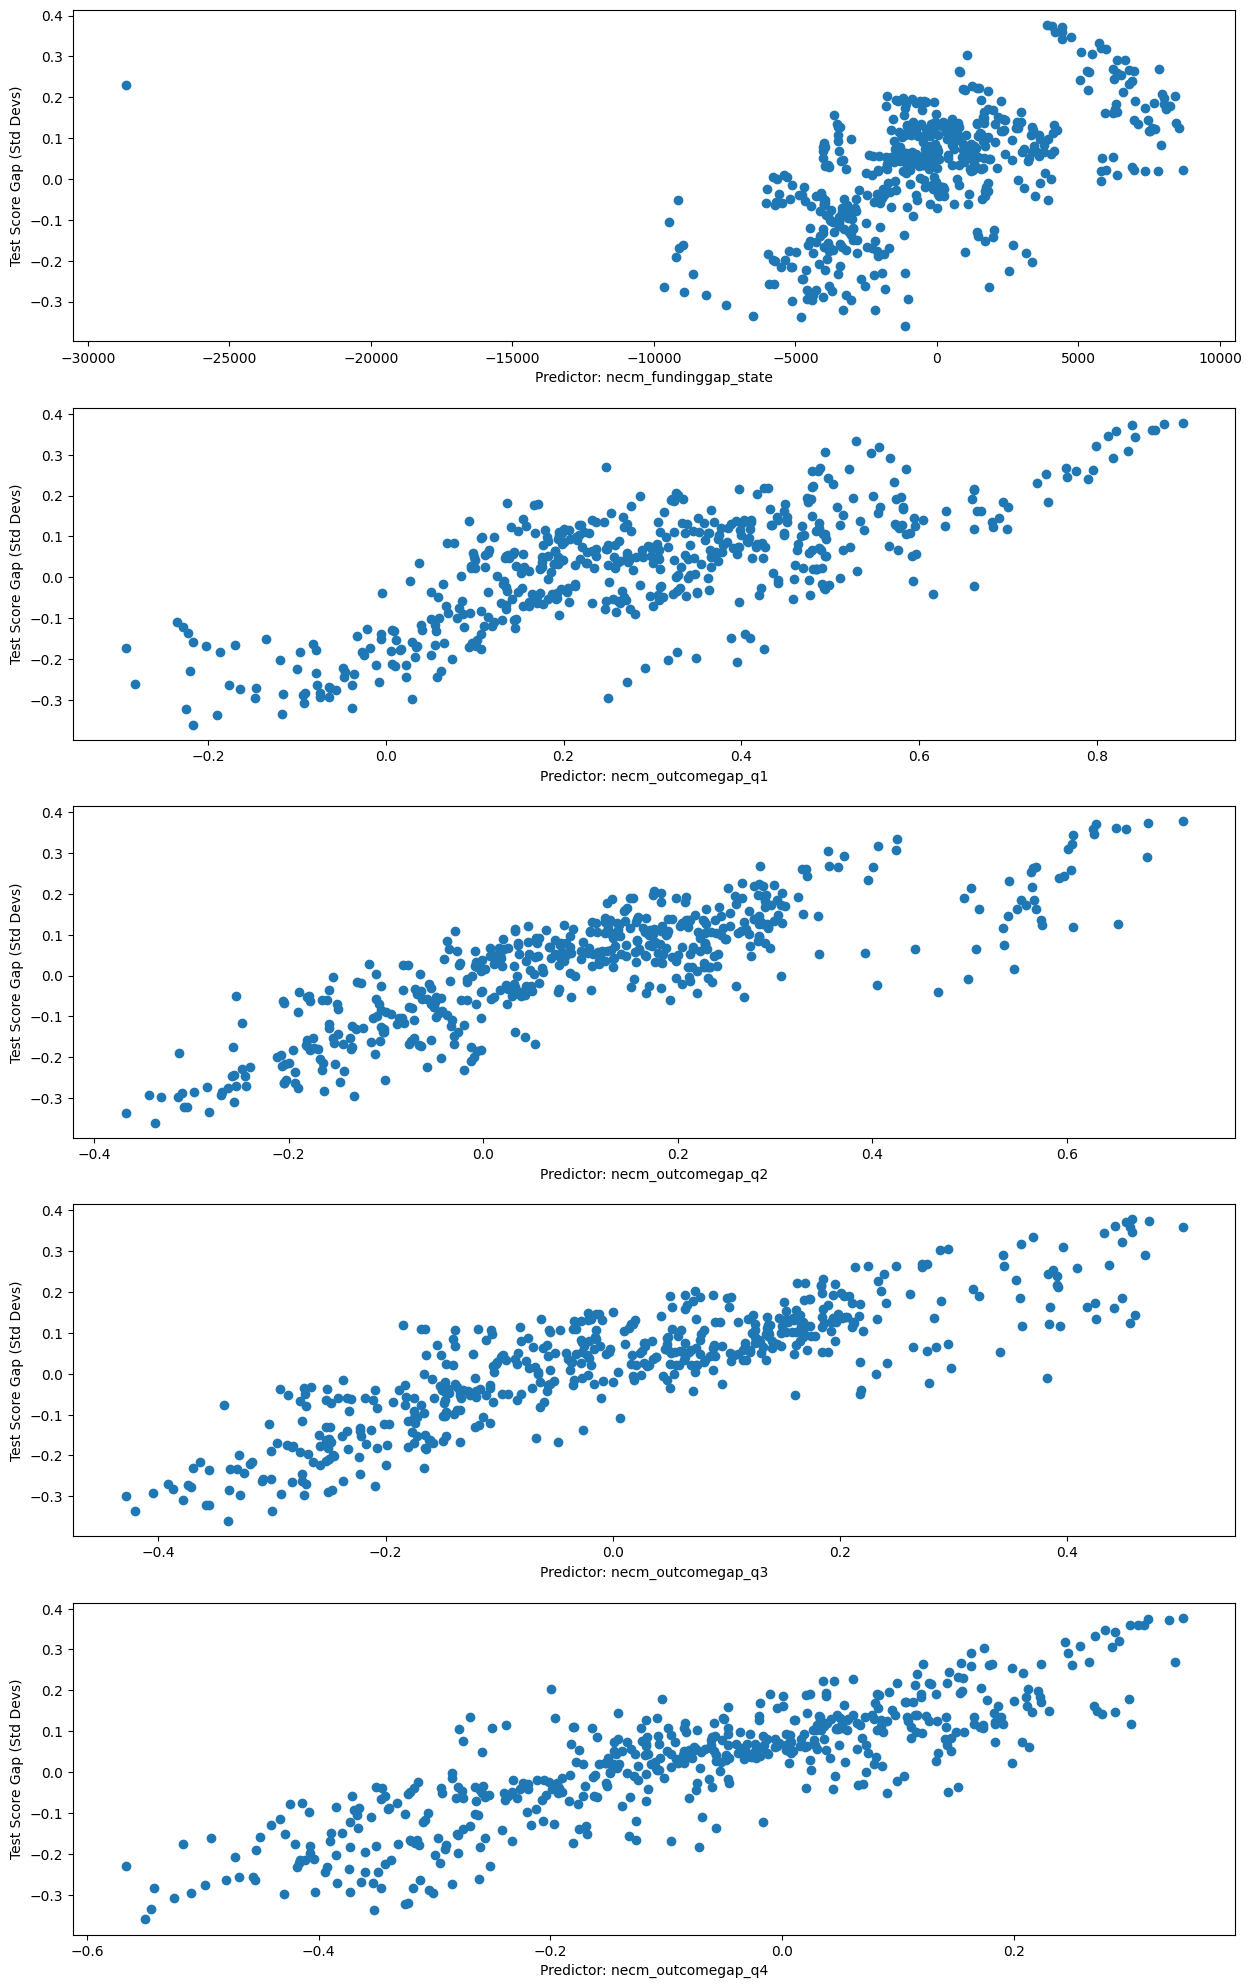

In [206]:
fig, axes = plt.subplots(5, 1, figsize=(15, 25), sharey=True)

for pred, ax in zip(predictors_of_interest, axes.flatten()):
    ax.scatter(filtered_df[pred], filtered_df[response_var])
    ax.set_xlabel(f"Predictor: {pred}")
    ax.set_ylabel("Test Score Gap (Std Devs)")

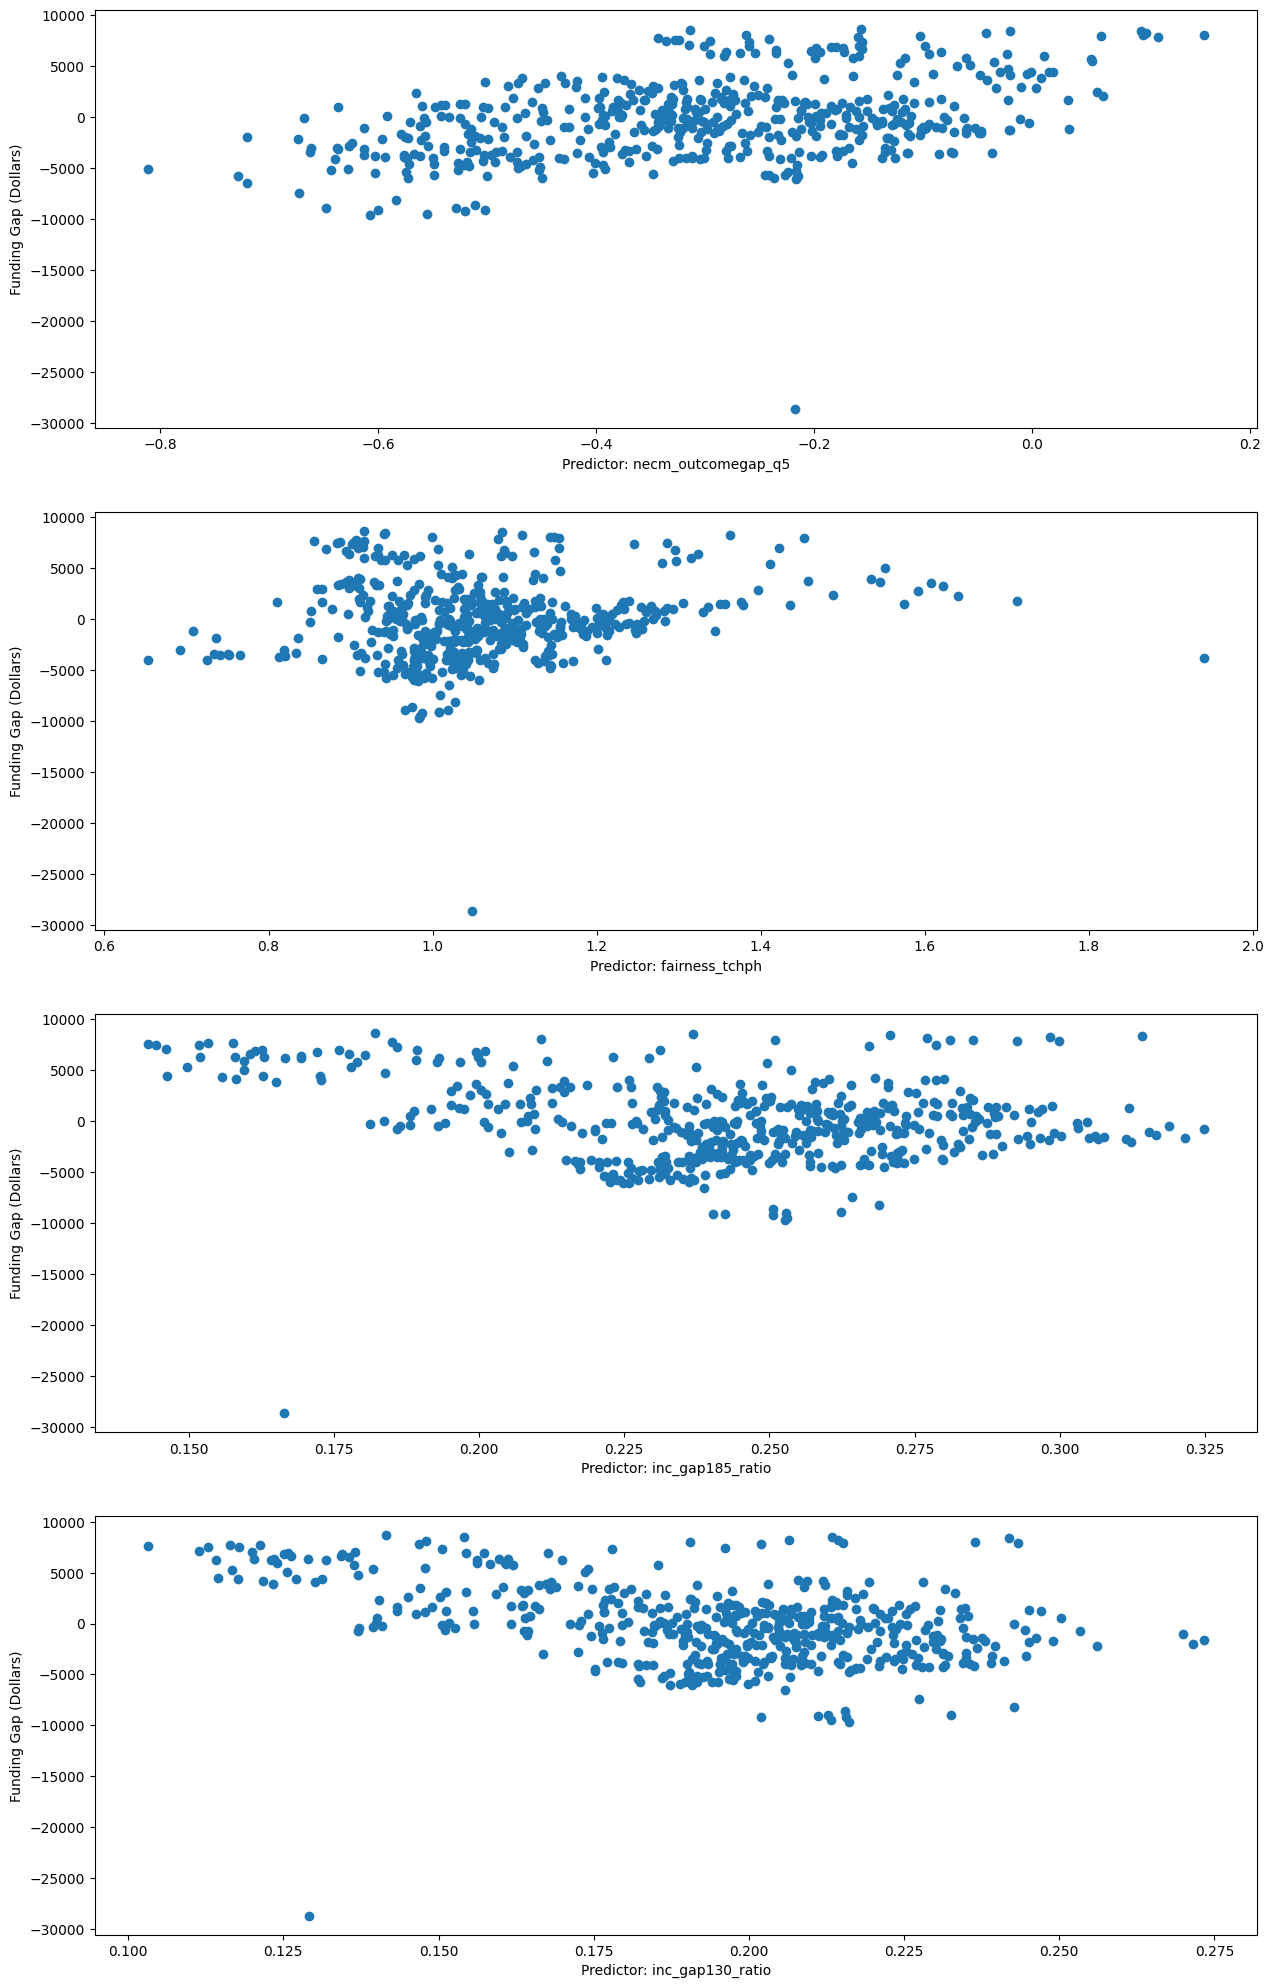

In [207]:
fig, axes = plt.subplots(4, 1, figsize=(15, 25), sharey=True)

for pred, ax in zip(predictors_of_interest[5:], axes.flatten()):
    ax.scatter(filtered_df[pred], filtered_df["necm_fundinggap_state"])
    ax.set_xlabel(f"Predictor: {pred}")
    ax.set_ylabel("Funding Gap (Dollars)")

## Baseline Multiple Linear Regression Model

In [208]:
X_pred = filtered_df[predictors_of_interest]
X_pred

,necm_fundinggap_state,necm_outcomegap_q1,necm_outcomegap_q2,necm_outcomegap_q3,necm_outcomegap_q4,necm_outcomegap_q5,fairness_tchph,inc_gap185_ratio,inc_gap130_ratio
0,-5113.8250,0.029665,-0.330956,-0.428685,-0.430291,-0.811346,0.911271,0.242321,0.197983
1,-2852.4060,0.246770,-0.073577,-0.269651,-0.424496,-0.626824,0.945713,0.243701,0.196911
2,-3977.7690,0.101952,-0.143908,-0.247667,-0.315275,-0.574663,1.210944,0.256912,0.214611
3,-1159.8540,0.404455,0.032169,-0.213023,-0.366004,-0.514552,0.990620,0.203774,0.164208
4,32.1782,0.336864,0.126460,-0.138817,-0.121889,-0.205673,1.146207,0.208257,0.151715
...,...,...,...,...,...,...,...,...,...
512,1204.0750,0.200655,0.073300,-0.074673,-0.060387,-0.126149,1.108799,0.203237,0.151159
513,999.2659,0.299809,0.089604,-0.025543,-0.105857,-0.384629,1.093844,0.258128,0.202769
514,2531.9530,-0.100142,-0.239789,-0.199455,-0.342680,-0.352378,1.051037,0.262266,0.217146
515,1877.1510,0.411591,0.167646,0.110004,-0.013257,-0.409739,1.002770,0.278322,0.213408


In [209]:

y_resp = filtered_df[response_var]

X_train, X_test, y_train, y_test = train_test_split(X_pred, y_resp, test_size=0.2, random_state=42, shuffle=True)

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [210]:
y_hat_train = model.predict(X_train)
mse_train = mean_squared_error(y_train, y_hat_train)
print(f"Training MSE: {mse_train}")


Training MSE: 0.0021299986361208263


In [211]:
y_hat_test = model.predict(X_test)
mse_test = mean_squared_error(y_test, y_hat_test)
r2_test = r2_score(y_test, y_hat_test)
print(f"Testing MSE: {mse_test}")
print(f"Testing R^2: {r2_test}")

Testing MSE: 0.002339793374631087
Testing R^2: 0.8706589491139705


In [220]:
intercept = model.intercept_
coefficients = model.coef_
feature_names = X_train.columns

In [ ]:
pd.DataFrame({"Coefficients": coefficients, "Predictors": feature_names})

,Coefficients,Predictors
0,-0.000003,necm_fundinggap_state
1,0.262530,necm_outcomegap_q1
2,0.077356,necm_outcomegap_q2
3,0.050191,necm_outcomegap_q3
4,0.199515,necm_outcomegap_q4
5,0.220561,necm_outcomegap_q5
6,0.141771,fairness_tchph
7,1.075714,inc_gap185_ratio
8,-1.112705,inc_gap130_ratio


In [ ]:



formula = f"Y = {intercept:.4f}"
for i, coef in enumerate(coefficients):
    formula += f" + {coef:.4f} * {feature_names[i]}"

print("Multiple Linear Regression Formula:")
print(formula)

Multiple Linear Regression Formula:
Y = -0.1749 + -0.0000 * necm_fundinggap_state + 0.2625 * necm_outcomegap_q1 + 0.0774 * necm_outcomegap_q2 + 0.0502 * necm_outcomegap_q3 + 0.1995 * necm_outcomegap_q4 + 0.2206 * necm_outcomegap_q5 + 0.1418 * fairness_tchph + 1.0757 * inc_gap185_ratio + -1.1127 * inc_gap130_ratio


### Cross Validation

In [213]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_mean_squared_error')
cv_rmse_scores = np.sqrt(np.abs(cv_scores))

print(f"Cross-validated RMSE scores: {cv_rmse_scores}")
print(f"Mean Cross-validated RMSE: {np.mean(cv_rmse_scores):.2f}")

Cross-validated RMSE scores: [0.05458173 0.04805273 0.04011465 0.04537928 0.05516134]
Mean Cross-validated RMSE: 0.05


### Residual Analysis

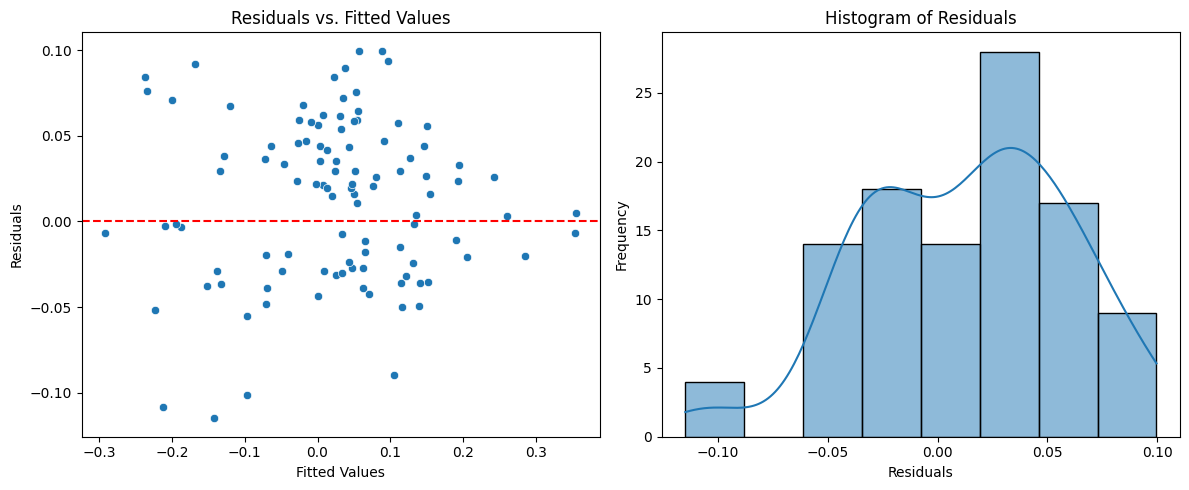

In [214]:
residuals = y_test - y_hat_test

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_hat_test, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')

plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()